1. 📦 Imports

In [202]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

2. 📥 Load Data

In [204]:
df = pd.read_csv("train.csv")


In [205]:
# target
y = df["price"]
X = df.drop(["price"], axis=1)

3. 🧹 Handle Missing Values

In [206]:
# fill numeric missing values
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = X[num_cols].fillna(X[num_cols].median())

# fill categorical missing values
cat_cols = X.select_dtypes(include="object").columns
X[cat_cols] = X[cat_cols].fillna("None")

In [ ]:
binary_cols = [
    "mainroad", "guestroom", "basement",
    "hotwaterheating", "airconditioning", "prefarea"
]

for col in binary_cols:
   X[col] = X[col].map({"yes":1,"no":0})
 

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0
...,...,...,...,...,...,...
540,1,0,1,0,0,0
541,0,0,0,0,0,0
542,1,0,0,0,0,0
543,0,0,0,0,0,0


In [208]:
X = pd.get_dummies(X, columns=["furnishingstatus"], drop_first=True)

In [209]:
X.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [210]:
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

5. 📏 Train/Test Split

In [211]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6. 📊 Normalization (VERY important for NN)

In [213]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# log transform target (recommended for house prices)
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)

{'whiskers': [<matplotlib.lines.Line2D at 0x175a0fb2c10>,
 'caps': [<matplotlib.lines.Line2D at 0x175a0fb2e90>,
 'boxes': [<matplotlib.lines.Line2D at 0x175a0fb2ad0>,
 'medians': [<matplotlib.lines.Line2D at 0x175a0fb3110>,
 'fliers': [<matplotlib.lines.Line2D at 0x175a0fb3250>,
 'means': []}

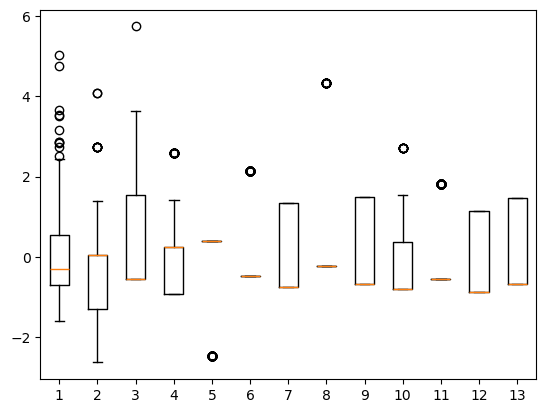

In [214]:
plt.boxplot(X_train)

In [215]:
X_train.shape

(436, 13)

7. 🔁 Convert to Torch Tensors

In [216]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)

8. 🧱 Dataset Class

In [217]:
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

9. 📦 DataLoader

In [218]:
train_ds = HouseDataset(X_train, y_train)
val_ds = HouseDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

10. 🧠 Neural Network Model

In [348]:
class HousePriceModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
          
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.net(x)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = HousePriceModel(X_train.shape[1]).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.0001 ,momentum=0.95,weight_decay=.00001)  
# scheduler = torch.optim.lr_scheduler.StepLR(
#     optimizer,
#     step_size=100,   # every 10 epochs
#     gamma=0.5       # reduce LR by half
# )
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # we minimize loss
    factor=0.5,        # reduce LR by half
    patience=5,        # wait 5 epochs before reducing
     )


12. 🔁 Training Loop

In [349]:
train_losses = []
val_losses = []

epochs = 1000

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        preds = model(X_batch)
        loss = loss_fn(preds, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # validation
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)
            val_loss += loss.item()
         

    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    scheduler.step(val_loss)      
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}: Train={train_loss:.4f}, Val={val_loss:.4f}")

Epoch 1: Train=236.0297, Val=231.1741
Epoch 2: Train=219.6888, Val=209.3538
Epoch 3: Train=192.9793, Val=175.1159
Epoch 4: Train=143.2464, Val=95.7854
Epoch 5: Train=37.3696, Val=31.7243
Epoch 6: Train=21.6644, Val=7.8740
Epoch 7: Train=12.2075, Val=6.7434
Epoch 8: Train=3.1762, Val=5.5620
Epoch 9: Train=2.3916, Val=1.8463
Epoch 10: Train=1.7047, Val=0.9594
Epoch 11: Train=0.7705, Val=0.9756
Epoch 12: Train=0.5938, Val=0.7337
Epoch 13: Train=0.5606, Val=0.5412
Epoch 14: Train=0.4202, Val=0.5122
Epoch 15: Train=0.3647, Val=0.5013
Epoch 16: Train=0.3532, Val=0.4451
Epoch 17: Train=0.3110, Val=0.4209
Epoch 18: Train=0.3027, Val=0.4081
Epoch 19: Train=0.2928, Val=0.4063
Epoch 20: Train=0.2792, Val=0.3814
Epoch 21: Train=0.2634, Val=0.3764
Epoch 22: Train=0.2589, Val=0.3668
Epoch 23: Train=0.2459, Val=0.3540
Epoch 24: Train=0.2431, Val=0.3489
Epoch 25: Train=0.2312, Val=0.3421
Epoch 26: Train=0.2223, Val=0.3306
Epoch 27: Train=0.2241, Val=0.3266
Epoch 28: Train=0.2087, Val=0.3200
Epoch 29: 

KeyboardInterrupt: 

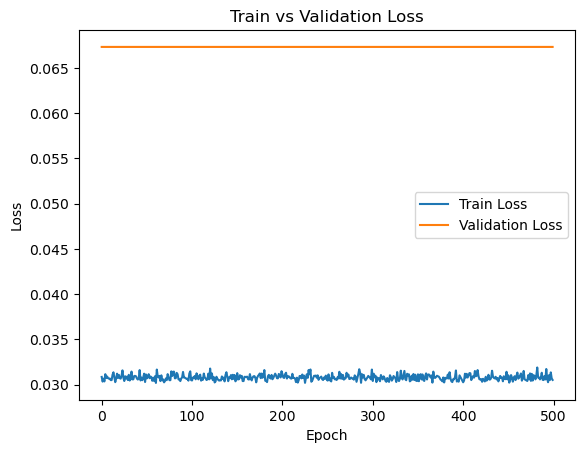

In [326]:
import matplotlib.pyplot as plt

plt.plot(train_losses[500:], label="Train Loss")
plt.plot(val_losses[500:], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")

plt.legend()
plt.show()

In [327]:
from sklearn.metrics import mean_absolute_error
model.eval()
index = 0
with torch.no_grad():
    pred = model(X_val[index].unsqueeze(0))
   
pred_real = torch.expm1(pred).item()
print("Prediction:", pred_real)
actual = torch.expm1(y_val[index]).item() 
print(f"Actual is {actual}")

percent_error = abs(pred_real-actual)/actual
print("Percent error:", percent_error)

  

Prediction: 3779157.5
Actual is 4060000.5
Percent error: 0.06917314419049948


In [328]:
model.eval()

with torch.no_grad():
    preds = model(X_val)

pred_real = torch.expm1(preds)
actual_real = torch.expm1(y_val)

mae = torch.mean(torch.abs(pred_real - actual_real))
rmse = torch.sqrt(torch.mean((pred_real - actual_real)**2))

print("Validation MAE:", mae.item())
print("Validation RMSE:", rmse.item())
 

Validation MAE: 1033561.8125
Validation RMSE: 1422474.125


In [331]:
mae_ratio = mae.item() / actual_real.mean().item()
print(mae_ratio)
 

0.2064012538900116
